In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_curve,
    auc
)

In [ ]:
print("Loading dataset...")
dataset = load_dataset("shahxeebhassan/human_vs_ai_sentences")
data = dataset["train"]

if len(data) > 5000:
    data = data.shuffle(seed=42).select(range(5000))

print("Total samples:", len(data))

Loading dataset...
Total samples: 5000


In [ ]:
train_test = data.train_test_split(test_size=0.30, seed=42)
test_valid = train_test["test"].train_test_split(test_size=0.50, seed=42)

train_ds = train_test["train"]
val_ds   = test_valid["train"]
test_ds  = test_valid["test"]

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

Train: 3500 Val: 750 Test: 750


In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/3500 [00:00<?, ? examples/s]

Map:   0%|          | 0/750 [00:00<?, ? examples/s]

Map:   0%|          | 0/750 [00:00<?, ? examples/s]

In [ ]:

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)


def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:

training_args = TrainingArguments(
    output_dir="./bert_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
    logging_strategy="steps",
    logging_steps=50,
    disable_tqdm=False
)

In [ ]:

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

/tmp/ipython-input-2623806692.py:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:

print("\nStarting training...\n")
trainer.train()
print("\nTraining finished!")


Starting training...



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.345900,0.326665,0.881333,0.825472,0.958904,0.887199
2,0.212400,0.463278,0.861333,0.786813,0.980822,0.873171
3,0.109500,0.494119,0.876000,0.807692,0.978082,0.884758



Training finished!


In [ ]:

print("\n===== TEST METRICS =====")
results = trainer.evaluate(test_ds)

print(f"Accuracy : {results['eval_accuracy']:.4f}")
print(f"Precision: {results['eval_precision']:.4f}")
print(f"Recall   : {results['eval_recall']:.4f}")
print(f"F1 Score : {results['eval_f1']:.4f}")


===== TEST METRICS =====


Accuracy : 0.8707
Precision: 0.8098
Recall   : 0.9679
F1 Score : 0.8819


In [ ]:

pred_output = trainer.predict(test_ds)

y_true = pred_output.label_ids
logits = pred_output.predictions
y_pred = np.argmax(logits, axis=1)
y_prob = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()


Confusion Matrix:
[[291  85]
 [ 12 362]]


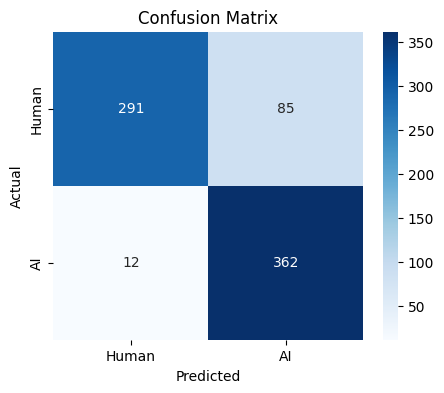

In [ ]:

cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Human", "AI"],
    yticklabels=["Human", "AI"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

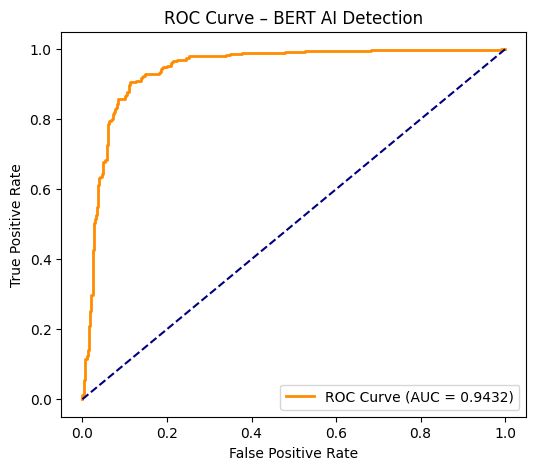

In [ ]:

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"ROC Curve (AUC = {roc_auc:.4f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", color="navy")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – BERT AI Detection")
plt.legend(loc="lower right")
plt.show()